In [149]:
import os
import sys
sys.path.append(os.path.abspath(".."))
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from etl.extractors import extract_data


In [150]:
df=extract_data("../data/raw/ebay_scraped.csv")

2026-03-25 21:14:49,482 - etl.extractors -INFO - Loaded 96 rows and 7 columns


In [151]:
df.head()

,Row_ID,Order_ID,Order_Date,Segment,Region,Product_Name,Sales
0,1,CA-2026-369326,12/06/2025,Home Office,East,JHK Ergonomic Mesh Office Chair Adjustable Hea...,69.99
1,2,CA-2026-426764,22/04/2025,Consumer,East,"Executive Office Ergonomic Chair, Computer Cha...",120.00
2,3,CA-2026-712456,22/11/2025,Corporate,South,Ergonomic Mesh Office Chair Adjustable Headres...,79.99
3,4,CA-2026-865155,30/06/2025,Home Office,Central,Marsail Ergonomic Office Desk Chair with High ...,99.00
4,5,CA-2026-415286,19/02/2026,Consumer,South,Sleekform Kneeling Chair Ergonomic Office Desk...,65.09


In [152]:
df.describe()

,Row_ID,Sales
count,96.000000,96.000000
mean,48.500000,129.840104
std,27.856777,108.895606
min,1.000000,10.200000
25%,24.750000,65.067500
50%,48.500000,91.820000
75%,72.250000,171.445000
max,96.000000,629.100000


In [153]:
df.dtypes

Row_ID            int64
Order_ID         object
Order_Date       object
Segment          object
Region           object
Product_Name     object
Sales           float64
dtype: object

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row_ID        96 non-null     int64  
 1   Order_ID      96 non-null     object 
 2   Order_Date    96 non-null     object 
 3   Segment       96 non-null     object 
 4   Region        96 non-null     object 
 5   Product_Name  96 non-null     object 
 6   Sales         96 non-null     float64
dtypes: float64(1), int64(1), object(5)
memory usage: 5.4+ KB


In [155]:
df.duplicated().sum()

np.int64(0)

In [156]:
df.shape

(96, 7)

In [157]:
df.isna().sum()

Row_ID          0
Order_ID        0
Order_Date      0
Segment         0
Region          0
Product_Name    0
Sales           0
dtype: int64

In [158]:
df=extract_data("../data/processed/ebay_cleaned.csv")

2026-03-25 21:14:49,607 - etl.extractors -INFO - Loaded 81 rows and 10 columns


In [159]:
df.describe()

,Row_ID,Sales,Profit
count,81.000000,81.000000,81.000000
mean,49.827160,148.563704,25.103580
std,28.279317,108.520965,20.434059
min,1.000000,50.520000,7.850000
25%,28.000000,75.190000,12.540000
50%,48.000000,112.280000,19.260000
75%,75.000000,192.050000,30.470000
max,96.000000,629.100000,135.830000


In [160]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Segment', 'Region', 'Product_Name',
       'Sales', 'Profit', 'Category', 'Sub-Category'],
      dtype='object')

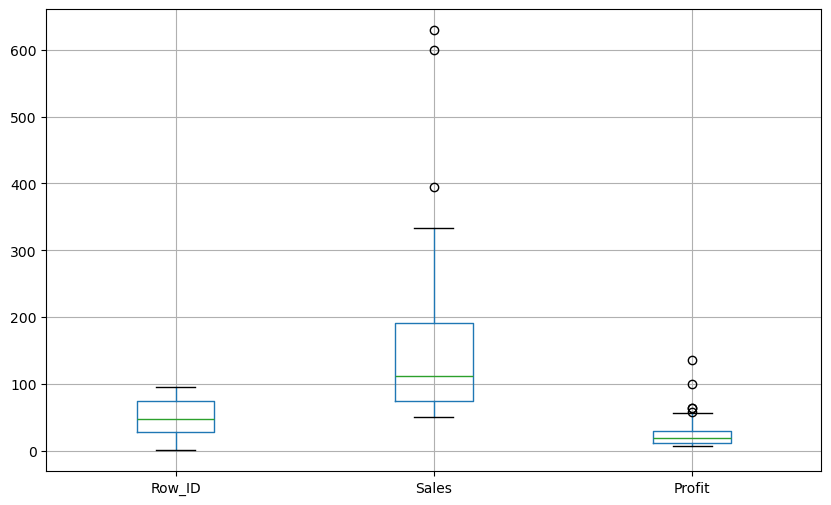

In [161]:
df.boxplot(figsize=(10,6))
plt.show()

### BoxPlot Visualization
**sales**
- Median is closer to the **Q1** that means more of the data is packed near lower end , it symbolizes the data is postivelly skewed.
- There are few outliers 

**profit**
- Median is closer to the **Q1** that means more of the data is packed near lower end , it symbolizes the data is postivelly skewed.
-  There are few outliers 

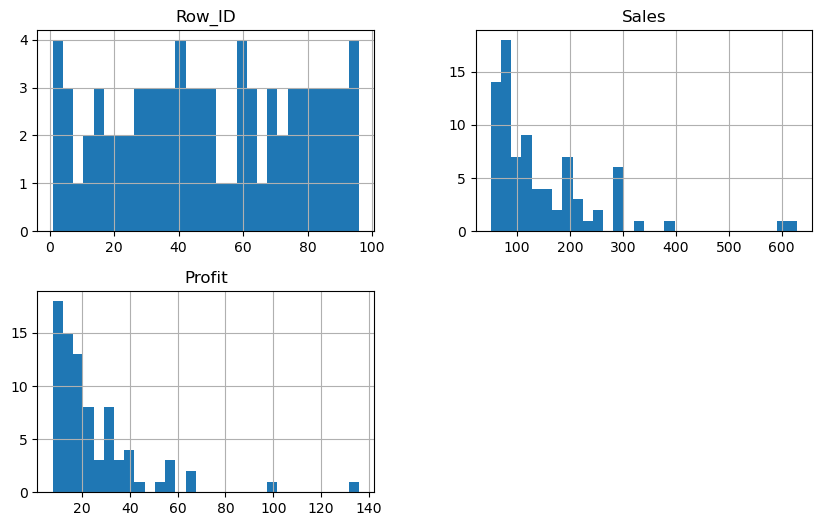

In [162]:
df.hist(figsize=(10,6),bins=30)
plt.show()

Most of the sales are concentrated in the lower price range (around $30–$60).  
This means the majority of products sold are not the pricey ones.  
The distribution is **positively skewed**, since there are a few very high sales values (outliers) stretching the tail to the right.

In [163]:
categorical_data=df.select_dtypes(include=['object','category'])
categorical_data.head()

,Order_ID,Order_Date,Segment,Region,Product_Name,Category,Sub-Category
0,CA-2026-369326,12/06/2025,Home Office,East,JHK Ergonomic Mesh Office Chair Adjustable Hea...,Furniture,Chairs
1,CA-2026-426764,22/04/2025,Consumer,East,"Executive Office Ergonomic Chair, Computer Cha...",Furniture,Chairs
2,CA-2026-712456,22/11/2025,Corporate,South,Ergonomic Mesh Office Chair Adjustable Headres...,Furniture,Chairs
3,CA-2026-865155,30/06/2025,Home Office,Central,Marsail Ergonomic Office Desk Chair with High ...,Furniture,Chairs
4,CA-2026-415286,19/02/2026,Consumer,South,Sleekform Kneeling Chair Ergonomic Office Desk...,Furniture,Chairs


/tmp/ipykernel_17782/1305147078.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=axes[i], palette="Set2")
/tmp/ipykernel_17782/1305147078.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=axes[i], palette="Set2")
/tmp/ipykernel_17782/1305147078.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=axes[i], palette="Set2")
/tmp/ipykernel_17782/1305147078.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wil

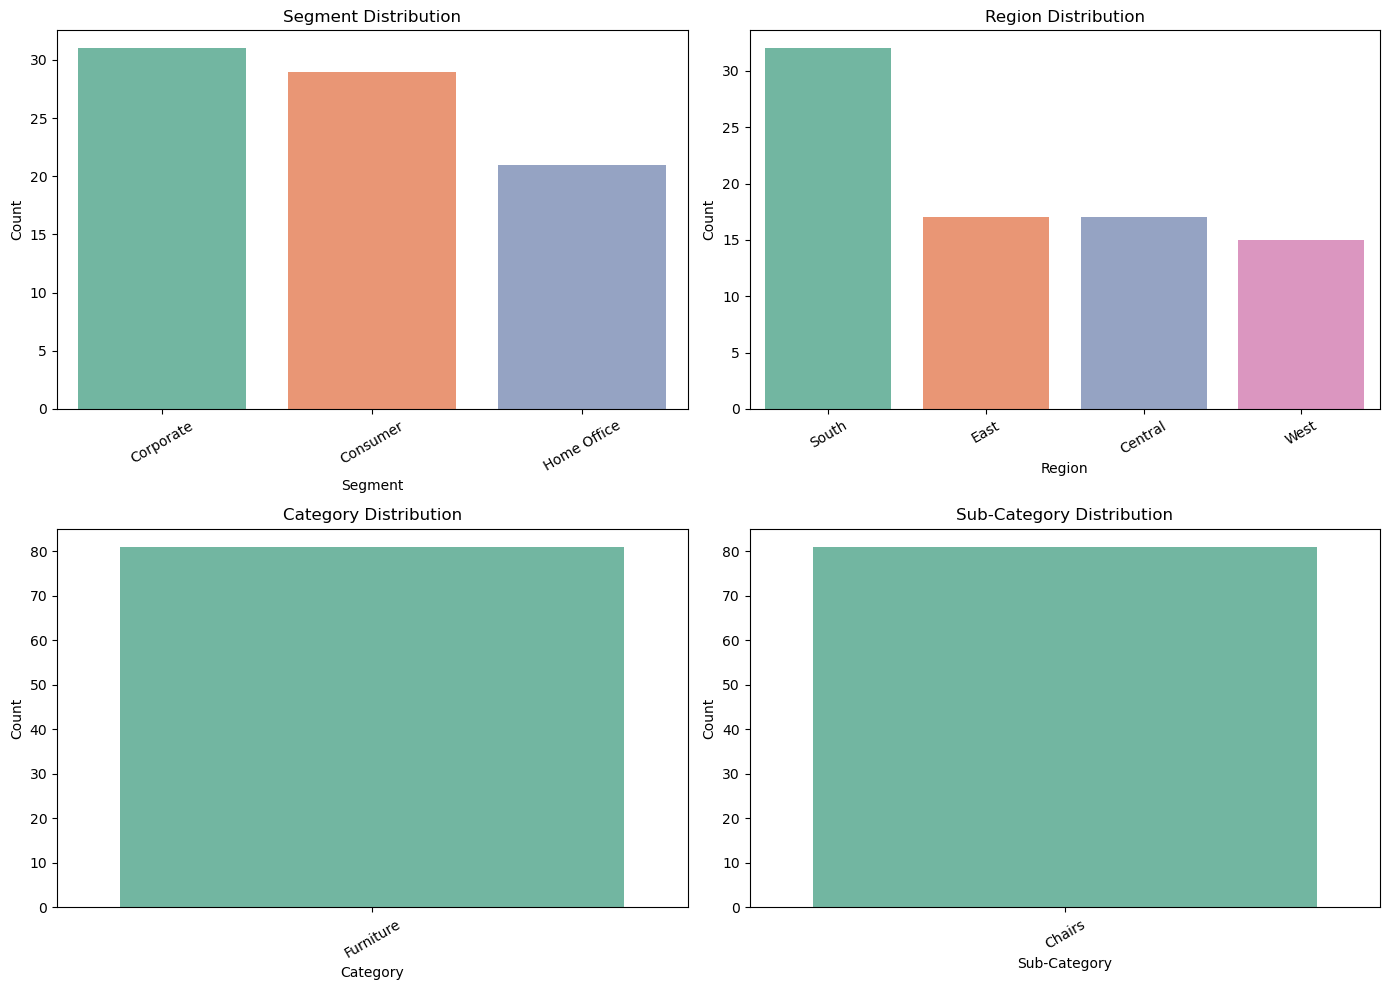

In [164]:
low_card_cols = ["Segment", "Region", "Category", "Sub-Category"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(low_card_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

/tmp/ipykernel_17782/2617523275.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=top_order, palette="viridis")


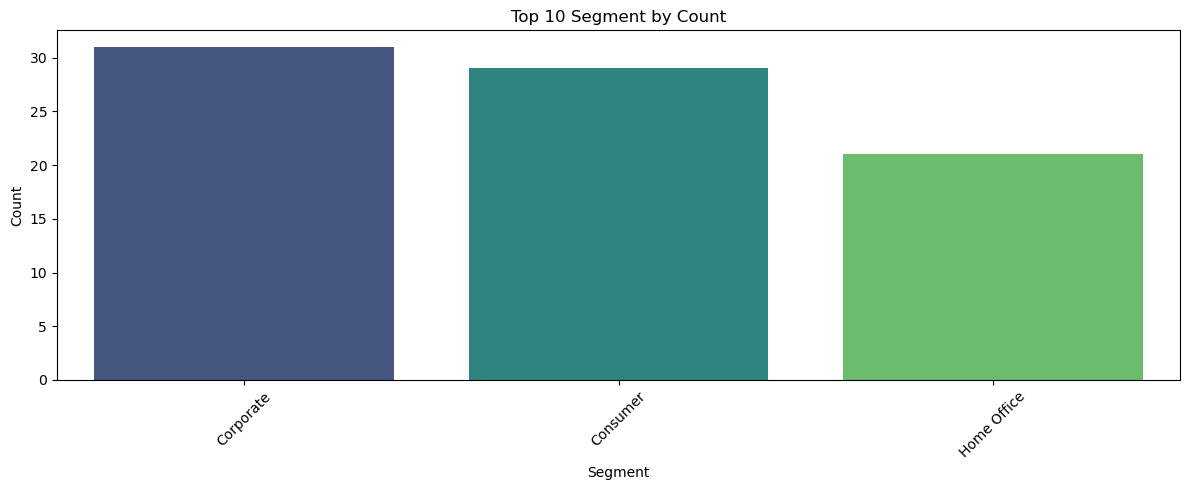

In [165]:
top_n = 10
col = "Segment"
top_order = df[col].value_counts().head(top_n).index

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x=col, order=top_order, palette="viridis")
plt.title(f"Top {top_n} {col} by Count")
plt.xlabel(col)
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [166]:
df.head()

,Row_ID,Order_ID,Order_Date,Segment,Region,Product_Name,Sales,Profit,Category,Sub-Category
0,1,CA-2026-369326,12/06/2025,Home Office,East,JHK Ergonomic Mesh Office Chair Adjustable Hea...,69.99,10.01,Furniture,Chairs
1,2,CA-2026-426764,22/04/2025,Consumer,East,"Executive Office Ergonomic Chair, Computer Cha...",120.00,23.62,Furniture,Chairs
2,3,CA-2026-712456,22/11/2025,Corporate,South,Ergonomic Mesh Office Chair Adjustable Headres...,79.99,13.02,Furniture,Chairs
3,4,CA-2026-865155,30/06/2025,Home Office,Central,Marsail Ergonomic Office Desk Chair with High ...,99.00,19.86,Furniture,Chairs
4,5,CA-2026-415286,19/02/2026,Consumer,South,Sleekform Kneeling Chair Ergonomic Office Desk...,65.09,8.99,Furniture,Chairs


In [167]:
salesperregion=(df.groupby("Region")['Sales'].sum().sort_values(ascending=False))
salesperregion.head()

Region
South      4996.81
West       2454.07
East       2424.52
Central    2158.26
Name: Sales, dtype: float64

In [168]:
salesandProductperregion = (
    df.groupby("Region")[["Sales", "Profit"]]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

salesandProductperregion

,Sales,Profit
Region,,
South,4996.81,859.05
West,2454.07,397.00
East,2424.52,415.35
Central,2158.26,361.99


In [169]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d/%m/%Y')

In [170]:
df['Year']=df['Order_Date'].dt.year
df['Month']=df['Order_Date'].dt.month

In [171]:
salesperYear=(df.groupby("Year")['Sales'].sum().sort_values(ascending=False))
salesperYear

Year
2025    9456.35
2026    2577.31
Name: Sales, dtype: float64

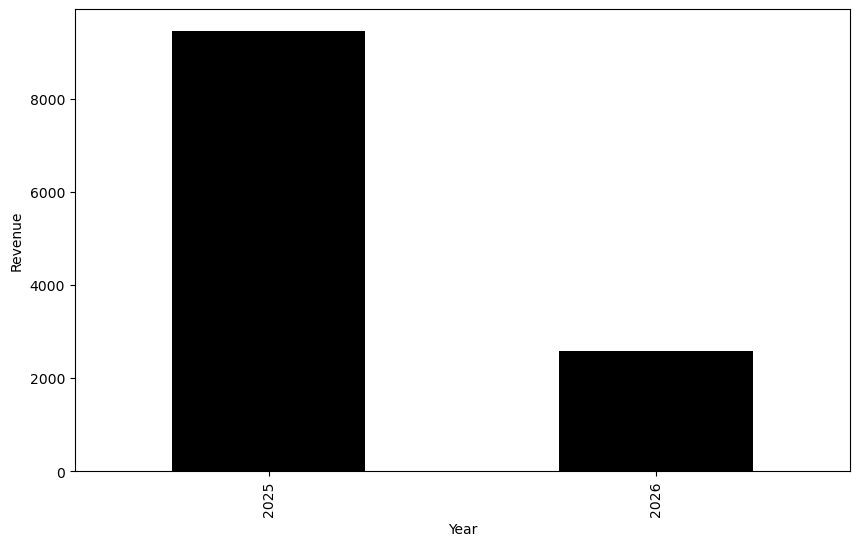

In [172]:
salesperYear.plot(kind="bar",figsize=(10,6),color="Black")
plt.ylabel("Revenue")
plt.show()

Month
12    1792.86
5     1502.81
1     1336.44
4     1303.41
10    1150.83
6     1132.95
3     1079.34
8      747.60
7      655.62
2      597.11
11     401.95
9      332.74
Name: Sales, dtype: float64


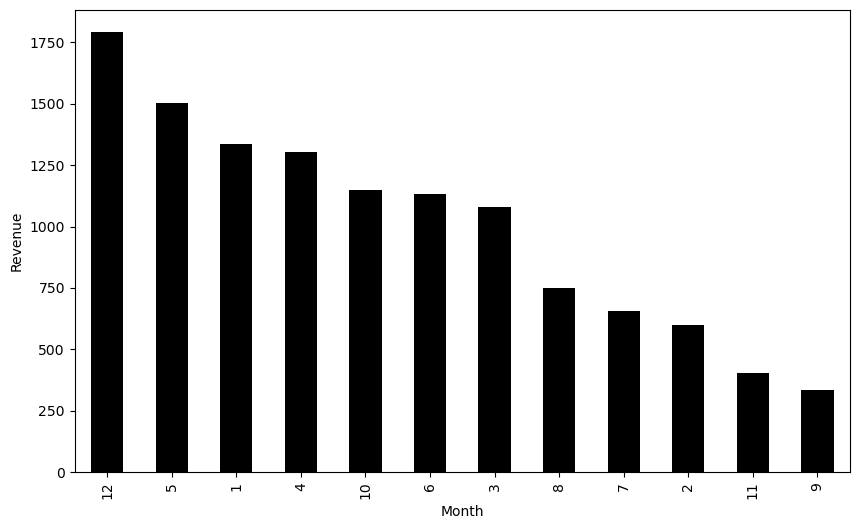

In [173]:
salespermonth=(df.groupby("Month")['Sales'].sum().sort_values(ascending=False))
print(salespermonth)
salespermonth.plot(kind="bar",figsize=(10,6),color="Black")
plt.ylabel("Revenue")
plt.show()


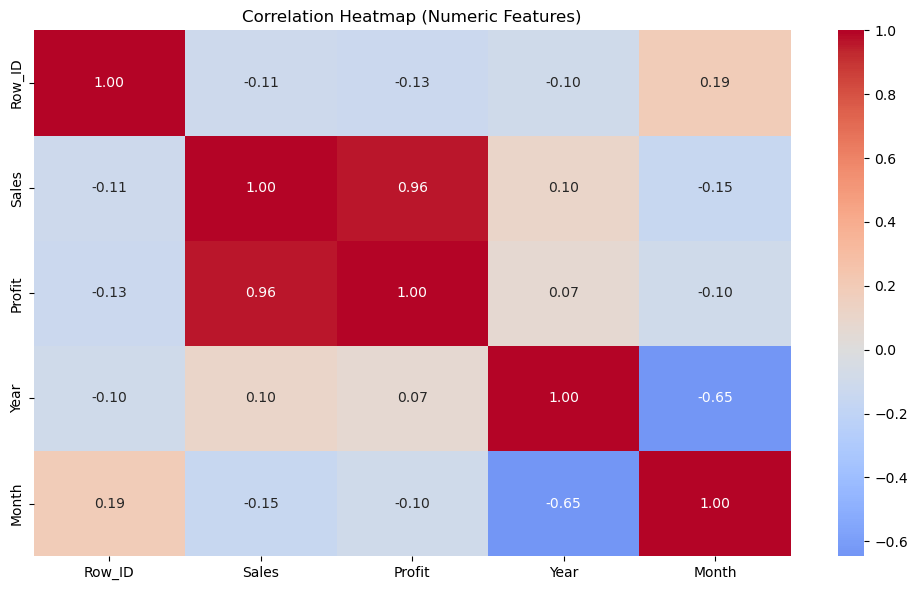

In [174]:

corr_matrix = df.corr(numeric_only=True)
corr_matrix
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

In [175]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Segment', 'Region', 'Product_Name',
       'Sales', 'Profit', 'Category', 'Sub-Category', 'Year', 'Month'],
      dtype='object')

In [176]:
drop_columns=['Row_ID', 'Order_ID', 'Order_Date', 'Product_Name',
       'Sales',  'Category', 'Sub-Category', 'Year', 'Month']
df_models=df.drop(columns=[col for col in drop_columns if col in df.columns],errors="ignore")


In [177]:
X=df_models.drop(columns=['Profit'],errors="ignore")
y=df_models['Profit']

In [178]:
categorical_features=X.columns.tolist()
type(categorical_features)

list

In [179]:
X_encoded=pd.get_dummies(X,drop_first=True)
X_encoded

,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West
0,False,True,True,False,False
1,False,False,True,False,False
2,True,False,False,True,False
3,False,True,False,False,False
4,False,False,False,True,False
...,...,...,...,...,...
76,False,True,False,True,False
77,False,True,False,False,False
78,False,False,False,False,False
79,True,False,False,False,False


In [180]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)



In [181]:
X_train,x_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)


In [182]:
model=LinearRegression()


In [183]:
model.fit(X_train, y_train)

LinearRegression()

In [184]:
y_pred=model.predict(x_test)

In [185]:

import numpy as np
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 16.738255577612676
RMSE: 29.08433975445425
R2: -0.017360840637815178


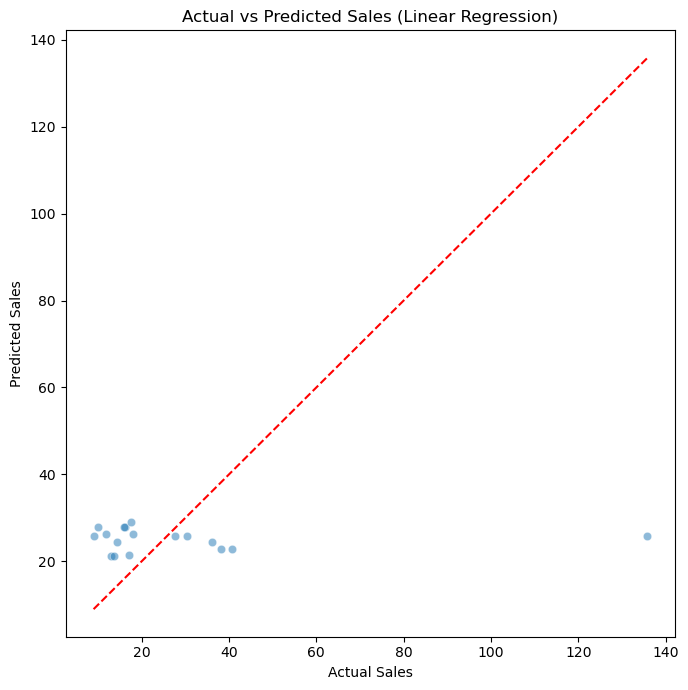

In [186]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Linear Regression)")
plt.tight_layout()
plt.show()

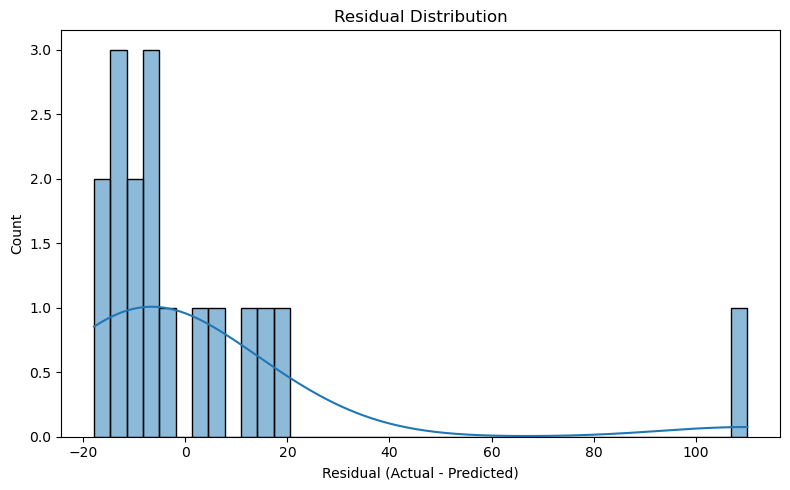

In [187]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()